### Illustrating the influence of `n_modes` on ROI stimulation

Here, we use the NFT wave model (`sim_nft_waves()`) to show how the `n_modes` parameter controls the
accuracy of simulations. For `n_modes` = `n_verts`, no modal approximation of the external input is
made. For a truncated basis (`n_modes` < `n_verts`), the `ext_input` provided is approximated by
fewer modes, similar to smoothing. By using a consistent input (local stimulation in Figs 1-2, white
noise in Figs 3-4), we can compare results across different `n_modes` to the true solution from
`sim_nft_waves(method='fem')` (equivalent to `n_modes`=`n_verts`).

In [85]:
from importlib.resources import as_file, files

import matplotlib.pyplot as plt
import numpy as np
from nsbutils.plotting import plot_surf
from scipy.sparse.linalg import splu

from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf
from neuromodes.stats import cdistw, meanw
from neuromodes.waves import _gen_noise


In [18]:
# Setup solver
surf, medmask = fetch_example_surf(density='4k')
solver = EigenSolver(surf, medmask)

In [91]:
# Params
n_modes = [solver.n_verts-1, 1000, 500, 100, 50, 10]
r = 17.4
gamma = 116
nt = 500
dt = 1e-4
seed = 0

In [92]:
solver.solve(n_modes=np.max(n_modes))

In [78]:
# Define an ROI
y_coords = solver.geometry.v[:, 1]
roi = np.where(y_coords < np.percentile(y_coords, 5))[0]

In [79]:
# Define external input as step function in the ROI
ext_input = np.zeros((solver.n_verts, nt))
ext_input[roi, :10] = 1.0

In [80]:
sim_ts = solver.sim_nft_waves(method='fem', ext_input=ext_input, r=r, gamma=gamma, dt=dt)

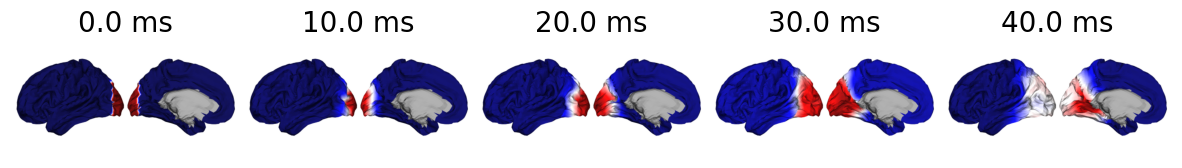

In [ ]:
# visualise some timepoints
surf_path = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-4k_hemi-L_midthickness.surf.gii'
t = np.array([0, 100, 200, 300, 400])

with as_file(surf_path) as surf_path:
    plot_surf(surf_path, solver.unmask_data(sim_ts[:, t]), labels=[f'{(i*dt*1e3).round()} ms' for i in t], cmap='seismic')

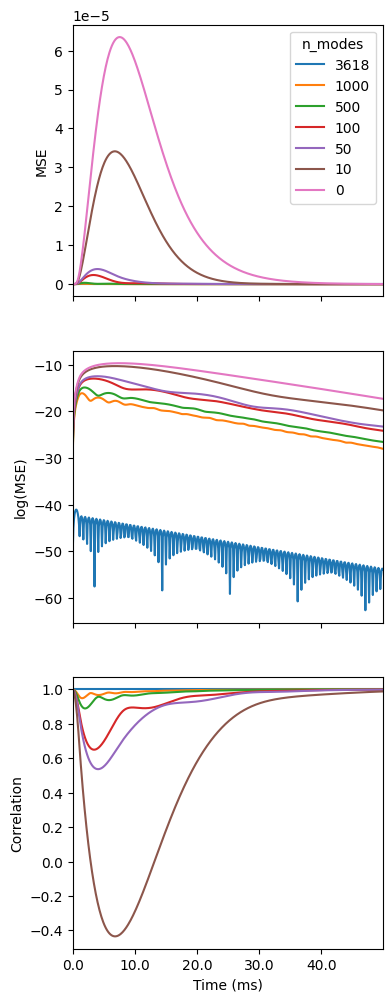

In [ ]:
# For each n_modes, truncate the output and compute error
sim_ts_coeffs = solver.decompose(sim_ts)

# create three subplots, one for MSE, one for log(MSE), and one for correlation
fig, ax = plt.subplots(3, 1, figsize=(4, 12), sharex=True)

for k in n_modes:
    sim_ts_coeffs[k:, :] = 0
    sim_ts_recon = solver.emodes @ sim_ts_coeffs
    mse = meanw((sim_ts - sim_ts_recon)**2, solver.mass)
    corr = 1-np.diag(cdistw(sim_ts, sim_ts_recon, solver.mass))
    ax[0].plot(mse, label=k)
    ax[1].plot(np.log(mse), label=k)
    ax[2].plot(corr, label=k)
mse0 = meanw(sim_ts**2, solver.mass)
ax[0].plot(mse0, label='0')
ax[1].plot(np.log(mse0), label='0')
ax[0].set_ylabel('MSE')
ax[1].set_ylabel('log(MSE)')
ax[2].set_ylabel('Correlation')
ax[0].set_xlim([0, nt-1])
ax[1].set_xlim([0, nt-1])
ax[2].set_xlim([0, nt-1])
ax[0].legend(title='n_modes', loc='upper right')
ax[2].set_xlabel('Time (ms)')
ax[2].set_xticks(t)
ax[2].set_xticklabels((t*dt*1e3).round())
plt.show()

In [87]:
# Try with white noise
ext_input = splu(solver.mass).solve(_gen_noise(n_samples=solver.n_verts, nt=nt, mass=solver.mass, seed=seed))

In [89]:
sim_ts_noise = solver.sim_nft_waves(method='fem', ext_input=ext_input, r=r, gamma=gamma, dt=dt)

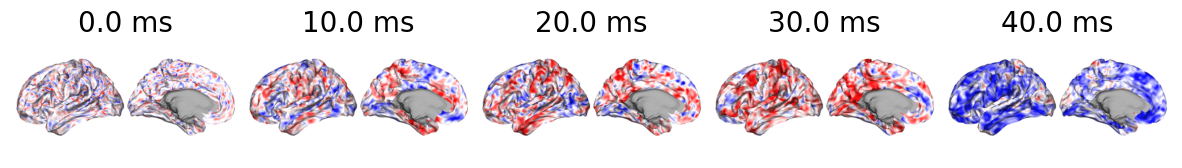

In [111]:
# plot activity
with as_file(surf_path) as surf_path:
    plot_surf(surf_path, solver.unmask_data(sim_ts_noise[:, t]), labels=[f'{(i*dt*1e3).round()} ms' for i in t], cmap='seismic')

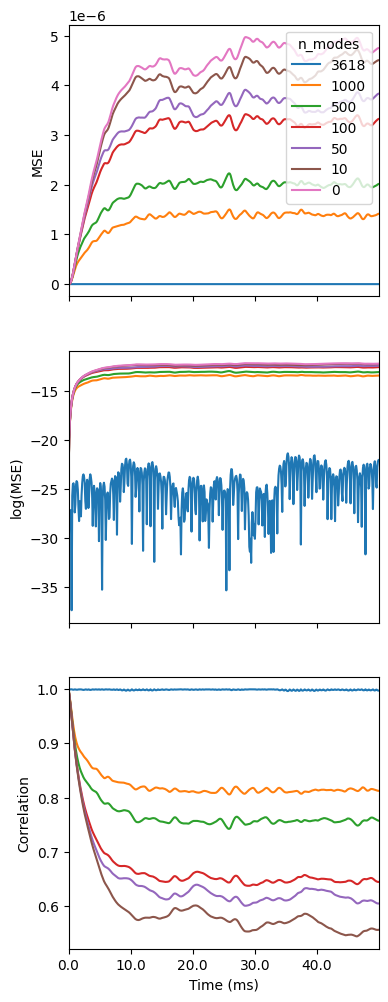

In [110]:
# For each n_modes, truncate the output and compute error
sim_ts_coeffs = solver.decompose(sim_ts_noise)
# create three subplots, one for MSE, one for log(MSE), and one for correlation
fig, ax = plt.subplots(3, 1, figsize=(4, 12), sharex=True)

for k in n_modes:
    sim_ts_coeffs[k:, :] = 0
    sim_ts_recon = solver.emodes @ sim_ts_coeffs
    mse = meanw((sim_ts_noise - sim_ts_recon)**2, solver.mass)
    corr = 1-np.diag(cdistw(sim_ts_noise, sim_ts_recon, solver.mass))
    ax[0].plot(mse, label=k)
    ax[1].plot(np.log(mse), label=k)
    ax[2].plot(corr, label=k)
mse0 = meanw(sim_ts_noise**2, solver.mass)
ax[0].plot(mse0, label='0')
ax[1].plot(np.log(mse0), label='0')
ax[0].set_ylabel('MSE')
ax[1].set_ylabel('log(MSE)')
ax[2].set_ylabel('Correlation')
ax[0].set_xlim([0, nt-1])
ax[1].set_xlim([0, nt-1])
ax[2].set_xlim([0, nt-1])
ax[0].legend(title='n_modes', loc='upper right')
ax[2].set_xlabel('Time (ms)')
ax[2].set_xticks(t)
ax[2].set_xticklabels((t*dt*1e3).round())
plt.show()